In [2]:
%load_ext autoreload
%autoreload 2

import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import gsw
# import regionate
import cartopy.crs as ccrs
# import CM4Xutils #needed to run pip install nc-time-axis
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import cartopy.feature as cfeature
import warnings
# from numpy import RankWarning
import cmocean as cm
warnings.filterwarnings('ignore')
import xesmf as xe

In [1]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='compute',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=8)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/bin/python -m distributed.cli.dask_worker tcp://172.16.3.101:35917 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.101:35917,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


2026-04-01 18:54:09,966 - tornado.application - ERROR - Uncaught exception GET /individual-workers-memory/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:9158', method='GET', uri='/individual-workers-memory/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.11/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.11/site-packages/tornado/web.py", line 3388, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.11/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is e

In [3]:
native_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/transient_tracers_z"
files = ["CM4Xp125_piControl_transient_tracers_z.zarr", "CM4Xp125_historical_transient_tracers_z.zarr", "CM4Xp125_ssp585_transient_tracers_z.zarr"]
full_depth_files = [native_path + "/" + a for a in files]

files = ["CM4Xp125_piControl_transient_tracers_surface.zarr", 
         "CM4Xp125_historical_transient_tracers_surface.zarr", 
         "CM4Xp125_ssp585_transient_tracers_surface.zarr"]
surface_files = [native_path + "/" + a for a in files]

In [4]:
def preprocess(ds):
    if ("year_ctrl" in ds.coords) or ("time_ctrl" in ds.coords):
        # if "time_ctrl" in ds.coords:
        #     ds = ds.reset_coords("year_ctrl", drop=True)
        # else:
        #     ds = ds.reset_coords("time_ctrl", drop=True)
        ds = ds.expand_dims(expt=["control"])
        ds.coords["year"] = ds.coords["year"]
        ds = ds.drop_vars(["year_ctrl"])
    else: 
        ds = ds.expand_dims(expt=["forced"])        
    return ds
ds_ctrl= xr.open_mfdataset(full_depth_files[0], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")
ds_forced = xr.open_mfdataset(full_depth_files[1:], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")

ds= xr.concat([ds_ctrl, ds_forced], dim = "expt").sel(year = slice(None, 2099))
ds["depth"] = approximate_z_bottom_up(ds, dim="z_l")

In [5]:
import gsw
p = xr.apply_ufunc(
    gsw.p_from_z, -np.abs(ds.depth), ds.lat,
    dask="parallelized", vectorize=True, output_dtypes=[float]
)

SA = xr.apply_ufunc(
    gsw.SA_from_SP, ds.so, p, ds.lon, ds.lat,
    dask="parallelized", vectorize=True, output_dtypes=[float]
)

CT = xr.apply_ufunc(
    gsw.CT_from_pt, SA, ds.thetao,
    dask="parallelized", vectorize=True, output_dtypes=[float]
)

ds["rho"] = xr.apply_ufunc(
    gsw.rho, SA, CT, p,
    dask="parallelized", vectorize=True, output_dtypes=[float]
).rename("rho")

ds["rho"].attrs["units"] = "kg m-3"

In [6]:
rename_geocoords = lambda ds: ds.rename({"lat":"old_lat", "lon":"old_lon"}).rename({"geolat":"lat", "geolon":"lon"})

def setup_regridder(ds, ds_locs):
    ds_tmp_coords = ds[["geolat", "geolon"]]
    ds_tmp_coords = rename_geocoords(ds_tmp_coords).compute()
    
    regridder = xe.Regridder(ds_tmp_coords, ds_locs, "bilinear", locstream_out=True)

    return regridder

def apply_regridder(regridder, ds):
    ds_sampled = regridder(ds.reset_coords(["geolon", "geolat", "wet"], drop = False))
    # ds_sampled = ds_sampled.drop_vars(['geolat_c', 'geolon_c', "xq", "yq"])
    ds_sampled = ds_sampled.set_coords(["wet", "geolon", "geolat"])
    for v in ds_sampled.data_vars:
        ds_sampled[v].attrs.update(ds[v].attrs)
    return ds_sampled

In [7]:
ds_locs = xr.Dataset()

ds_locs["lon"] = xr.DataArray(
    data=np.arange(-171, -168 + 1e-16, 0.02)[::-1], dims=("locations")
)
ds_locs["lat"] = xr.DataArray(
    data=np.linspace(-17.5, 10, len(ds_locs["lon"])), dims=("locations")
)

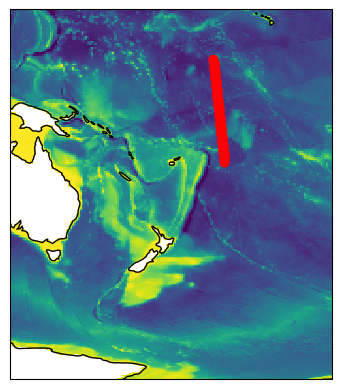

In [8]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree(central_longitude = 180)})

deptho_cropped = ds.sel(xh = slice(150, 320), yh = slice(50, 320), 
                        xq = slice(150, 321), yq = slice(50, 321),)

(-deptho_cropped["deptho"]).plot(x = "geolon", y = "geolat", transform = ccrs.PlateCarree(), add_colorbar = False)
plt.scatter(ds_locs["lon"], ds_locs["lat"], transform = ccrs.PlateCarree(), c = "r")
ax.coastlines()
# plt.xlim(240, 300)
# plt.ylim(-40, 10)

In [9]:
ds_chunked = ds.sel(xh = deptho_cropped.xh, yh = deptho_cropped.yh, 
                   xq = deptho_cropped.xq, yq = deptho_cropped.yq,
                   ).chunk(dict(z_l=-1, year = 1, xh = -1, yh = -1, expt = -1))
depth_target = -np.arange(2000, 6500, 100)
grid = Grid(ds_chunked, coords={'Z': {'center':'z_l'}}, periodic=False, autoparse_metadata=False)
vars_list = ["thetao", "sigma2", "cfc11", "sf6", "so", "volcello", "rho"]
# vars_list = ["sigma2", "volcello"]
ds_on_depth = xr.merge([grid.transform(ds_chunked[var], 'Z', depth_target, target_data=ds_chunked.depth) for var in vars_list])

ds_on_depth.coords["xq"] = ds_chunked.coords["xq"].compute()
ds_on_depth.coords["yq"] = ds_chunked.coords["yq"].compute()

In [10]:
import numpy as np
import xarray as xr
import xgcm

R = 6371000.0
DEG2M = np.pi * R / 180.0

def add_mom6_grid(ds):
    for c in ["geolon", "geolat"]:
        if c in ds.data_vars and c not in ds.coords:
            ds = ds.set_coords(c)

    xpos = "outer" if ds.sizes["xq"] == ds.sizes["xh"] + 1 else "right"
    ypos = "outer" if ds.sizes["yq"] == ds.sizes["yh"] + 1 else "right"

    grid = xgcm.Grid(
        ds,
        coords={
            "X": {"center": "xh", xpos: "xq"},
            "Y": {"center": "yh", ypos: "yq"},
        },
        periodic=["X"],
        autoparse_metadata=False,
    )
    return grid

def ddcoord(ds, axis):
    grid = add_mom6_grid(ds)
    
    bc = {} if axis == "X" else {"boundary": "fill", "fill_value": np.nan}
    
    dlon = grid.diff(grid._ds.geolon, axis, **bc)
    dlat = grid.diff(grid._ds.geolat, axis, **bc)

    dlon = ((dlon + 180.0) % 360.0) - 180.0
    lat = grid.interp(grid._ds.geolat, axis, **bc)

    ds_metric = DEG2M * np.sqrt((dlon * np.cos(np.deg2rad(lat)))**2 + dlat**2)
    return ds_metric

def ddvar(ds, var, axis):
    grid = add_mom6_grid(ds)

    bc = {} if axis == "X" else {"boundary": "fill", "fill_value": np.nan}
    ds_metric = ds.coords["dxCu"] if axis == "X" else ds.coords["dyCv"]

    dvar = grid.diff(grid._ds[var], axis, **bc)
    
    out = dvar / ds_metric
    out = grid.interp(out, axis, **bc)
    out.name = f"d{var}_d{axis.lower()}"
    return out

In [11]:
ds_on_depth.coords["dxCu"] = ddcoord(ds, "X").compute()

In [12]:
ds_on_depth["drho_dx"] = ddvar(ds_on_depth, "rho", "X")

In [ ]:
regridder = setup_regridder(ds_on_depth, ds_locs)
ds_remap = apply_regridder(regridder, ds_on_depth).compute()

In [ ]:
ds_masked = ds_remap.where(ds_remap.volcello > 0.0)
ds_masked = ds_masked.swap_dims({'locations': 'geolat'})

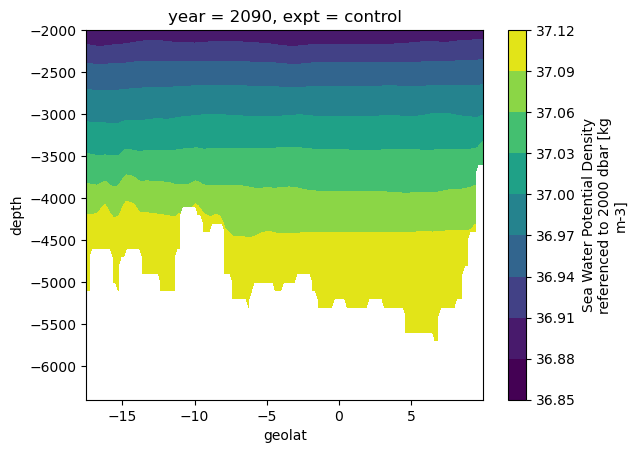

In [119]:
ds_masked.isel(expt = 0, year = -10).sigma2.plot.contourf()

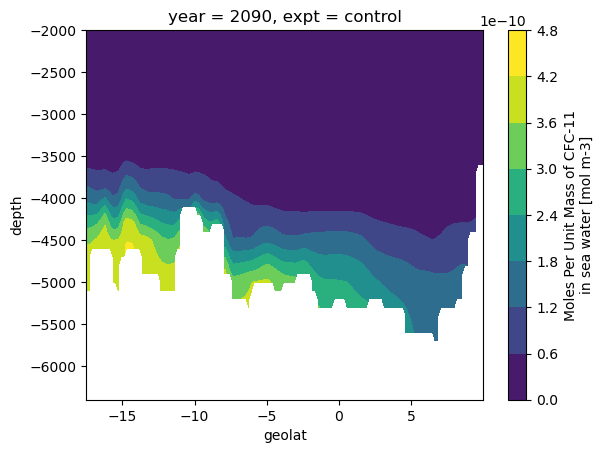

In [161]:
ds_masked.isel(expt = 0, year = -10).cfc11.plot.contourf()

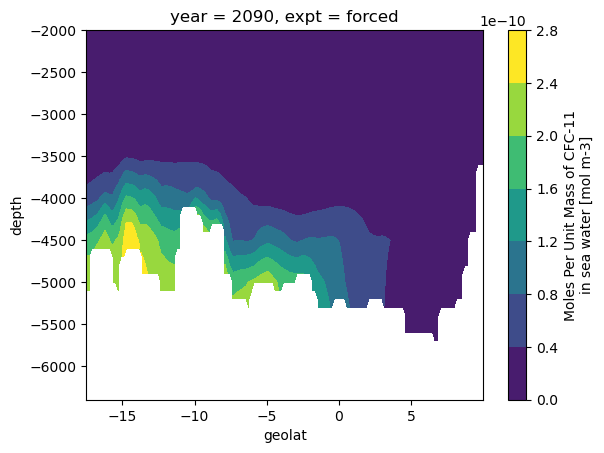

In [162]:
ds_masked.isel(expt = 1, year = -10).cfc11.plot.contourf()

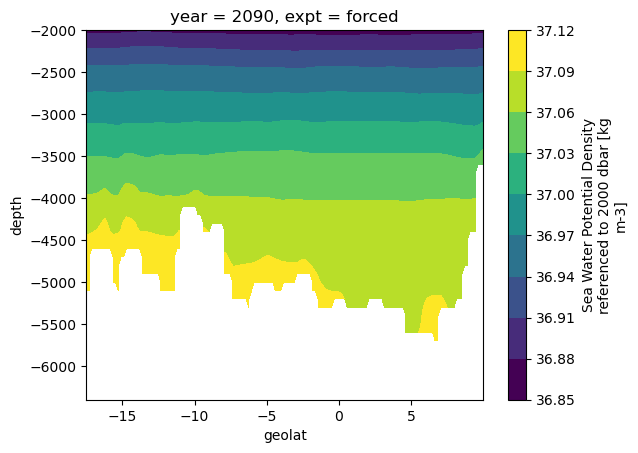

In [121]:
ds_masked.isel(expt = 1, year = -10).sigma2.plot.contourf()

In [150]:
def calculate_coriolis(latitude_deg):
    omega = 7.2921e-5  # Earth's angular velocity in rad/s
    lat_rad = np.deg2rad(latitude_deg)
    return 2 * omega * np.sin(lat_rad)
    
f = calculate_coriolis(ds_masked.geolat)
dz = 100
v_g = (-9.81 / (f * ds_masked.sigma2)) * ds_masked.dsigma_dx * dz

v_g = v_g.fillna(0.0).isel(depth = slice(None, None, -1)).cumsum("depth").isel(depth = slice(None, None, -1))

v_g = v_g.where(np.abs(v_g) > 0.0)

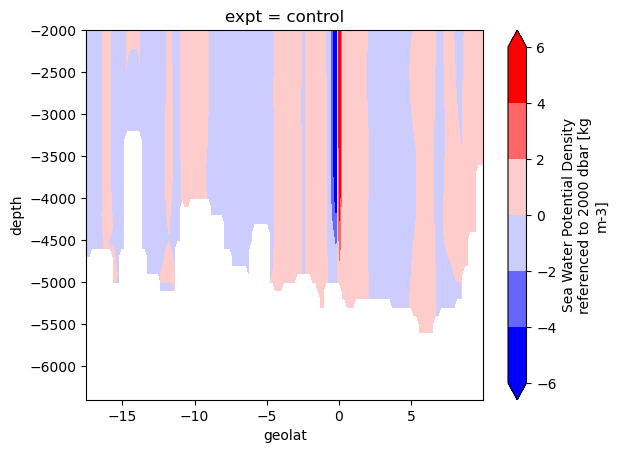

In [159]:
v_g.isel(expt = 0).mean("year").T.plot.contourf(vmin = -5, vmax = 5, cmap = "bwr")

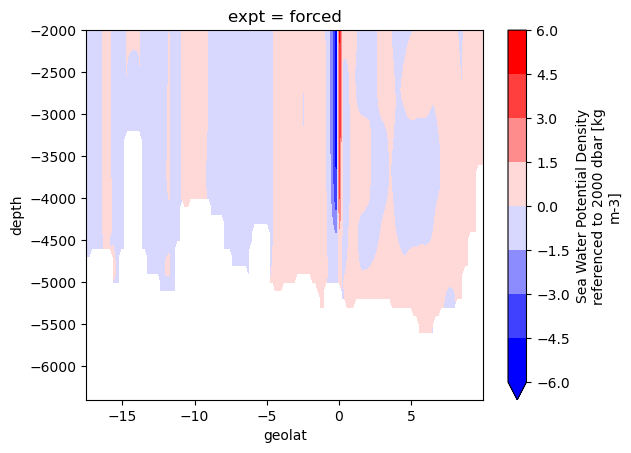

In [160]:
v_g.isel(expt = 1).mean("year").T.plot.contourf(vmin = -5, vmax = 5, cmap = "bwr")

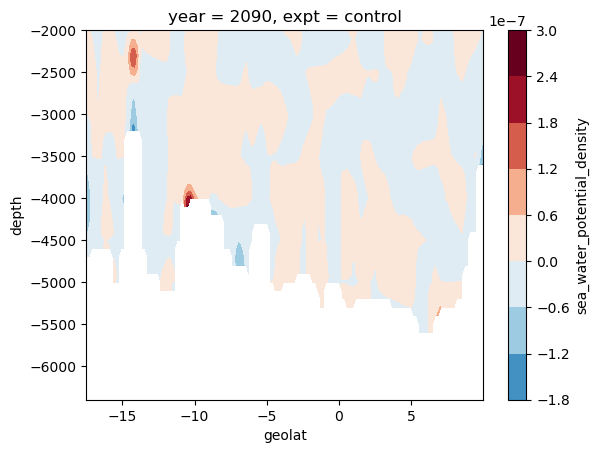

In [122]:
ds_masked.isel(expt = 0, year = -10).dsigma_dx.plot.contourf()

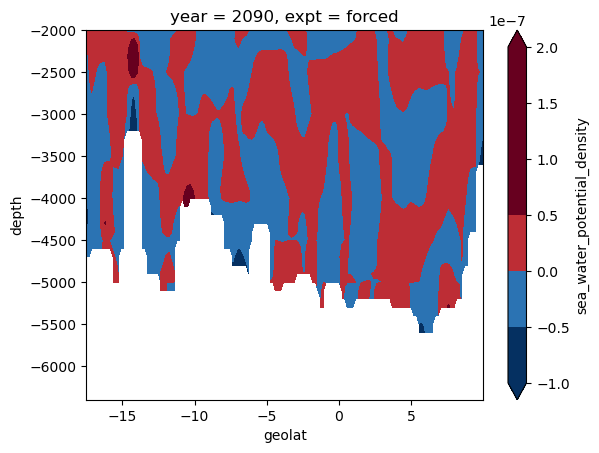

In [111]:
ds_masked.isel(expt = 1, year = -10).dsigma_dx.plot.contourf(robust = True)

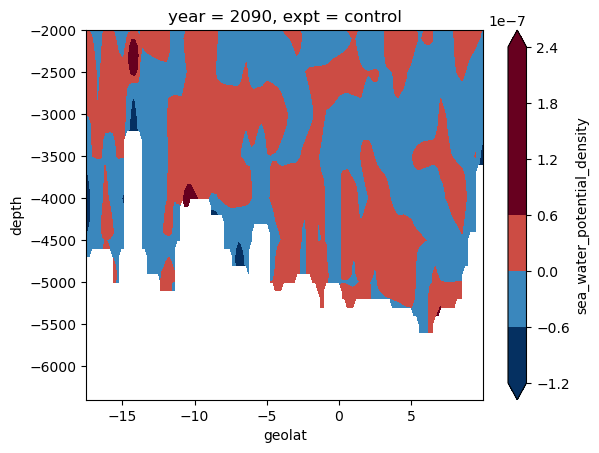

In [110]:
ds_masked.isel(expt = 0, year = -10).dsigma_dx.plot.contourf(robust = True)

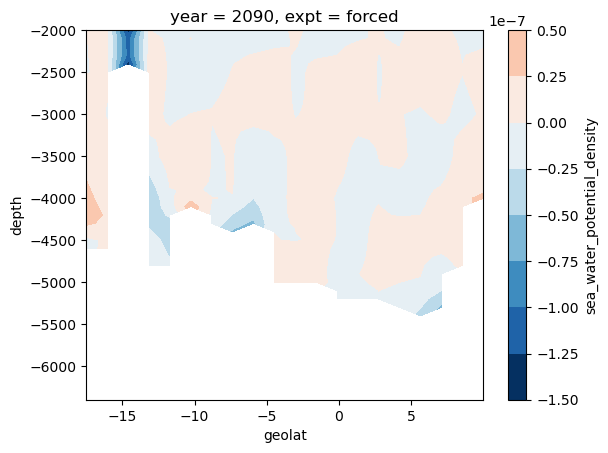

In [26]:
ds_masked.isel(expt = 1, year = -10).dsigma_dx.plot.contourf()

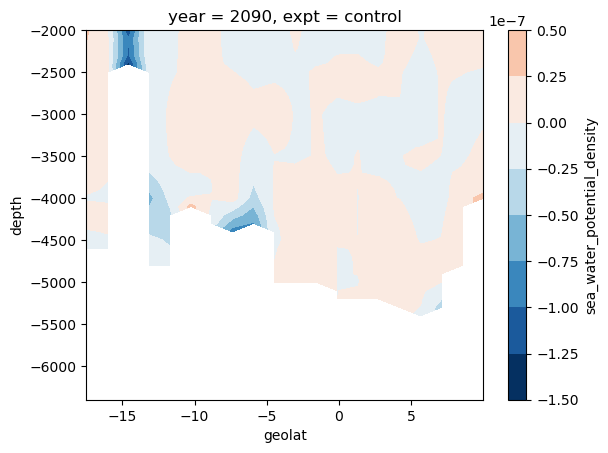

In [27]:
ds_masked.isel(expt = 0, year = -10).dsigma_dx.plot.contourf()

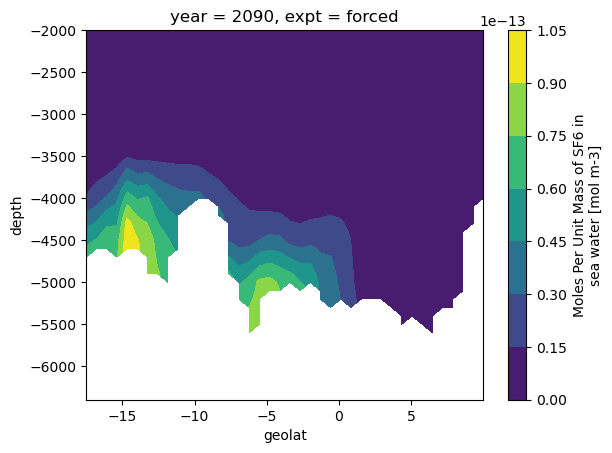

In [253]:
ds_masked.isel(expt = 1, year = -10).sf6.plot.contourf()

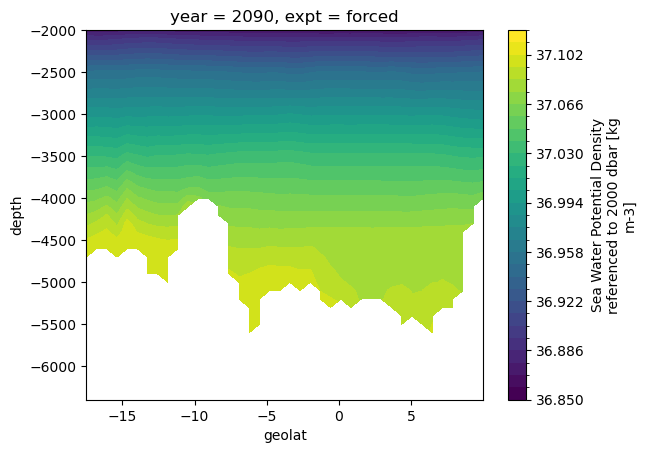

In [254]:
ds_masked.isel(expt = 1, year = -10).sigma2.plot.contourf(vmin = 36.85, vmax = 37.12, levels = 31)

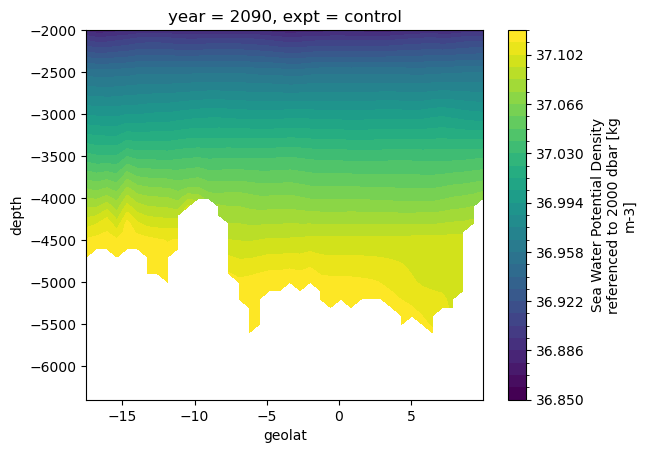

In [255]:
ds_masked.isel(expt = 0, year = -10).sigma2.plot.contourf(vmin = 36.85, vmax = 37.12, levels = 31)

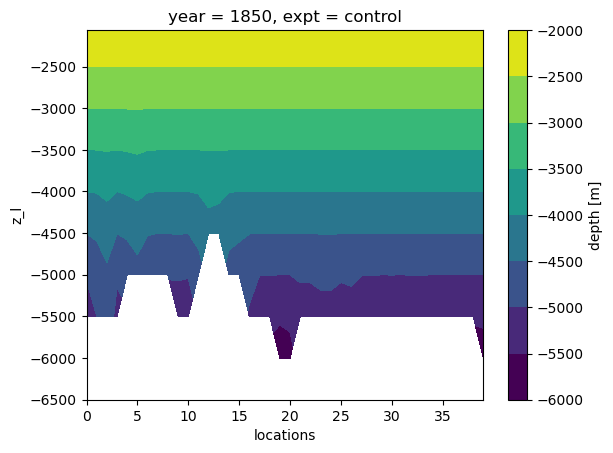

In [130]:
ds_cropped.depth.isel(expt = 0, year = 0).plot.contourf()

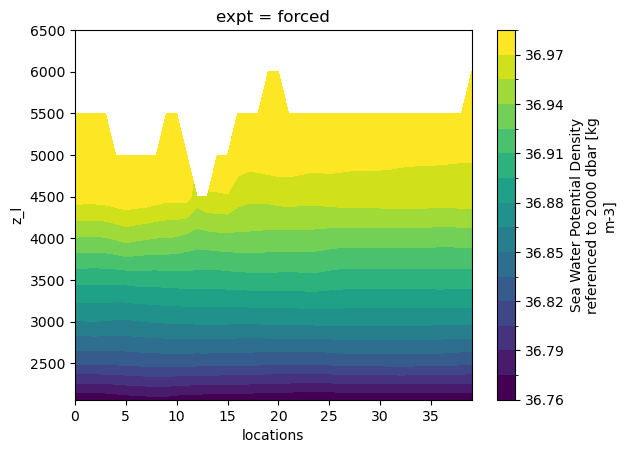

In [114]:
ds_cropped.sel(expt = "forced").mean("year").sigma2_offline.plot.contourf(levels = 21)

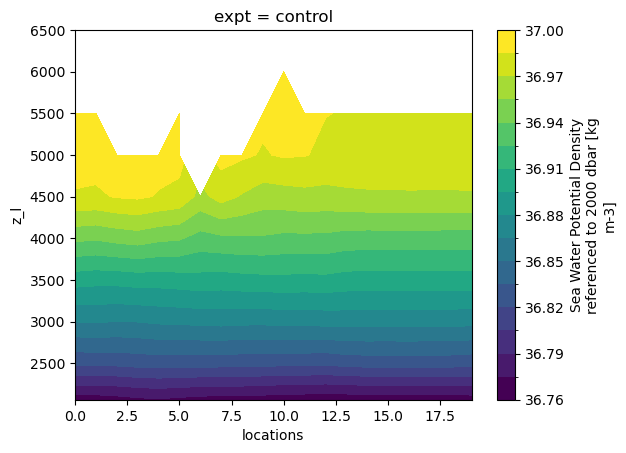

In [87]:
ds_cropped.sel(expt = "control").mean("year").sigma2_offline.plot.contourf(levels = 21)

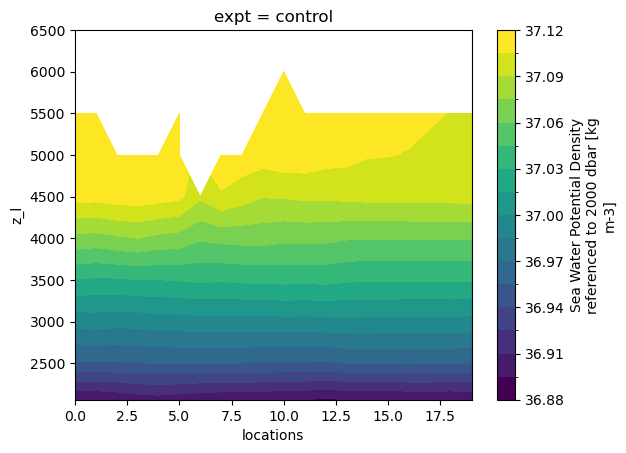

In [89]:
ds_cropped.sel(expt = "control").mean("year").sigma2.plot.contourf(levels = 21)

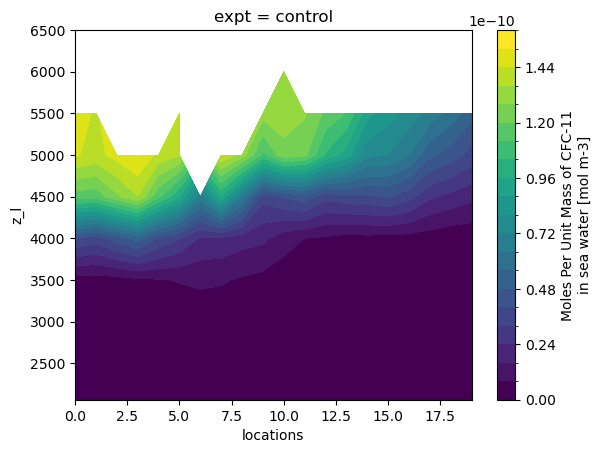

In [96]:
ds_cropped.sel(expt = "control").mean("year").cfc11.plot.contourf(levels = 21)

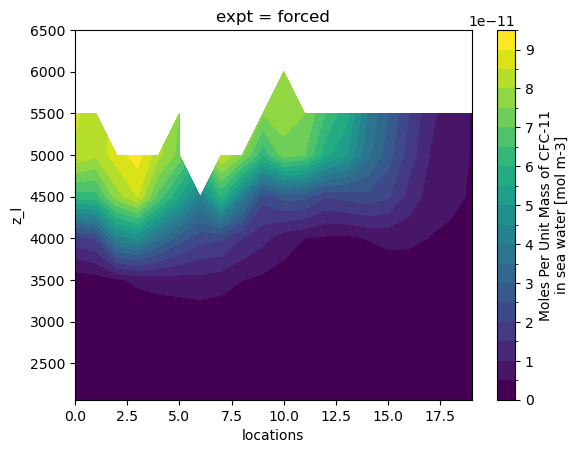

In [95]:
ds_cropped.sel(expt = "forced").mean("year").cfc11.plot.contourf(levels = 21)

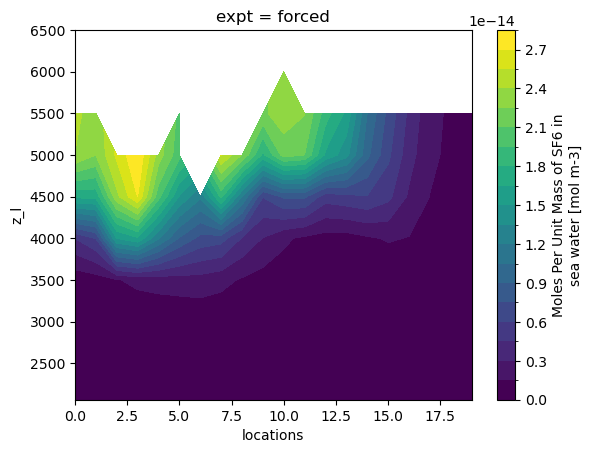

In [94]:
ds_cropped.sel(expt = "forced").mean("year").sf6.plot.contourf(levels = 21)

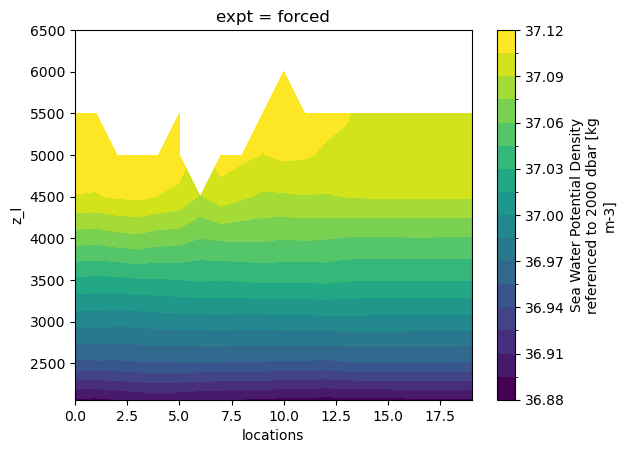

In [92]:
ds_cropped.sel(expt = "forced").mean("year").sigma2.plot.contourf(levels = 21)

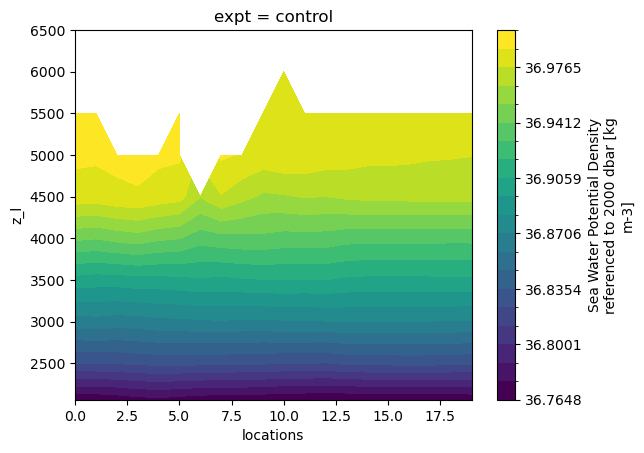

In [100]:
ds_cropped.sel(expt = "control").mean("year").sigma2_offline.plot.contourf(levels = 21, vmax = 37.0)

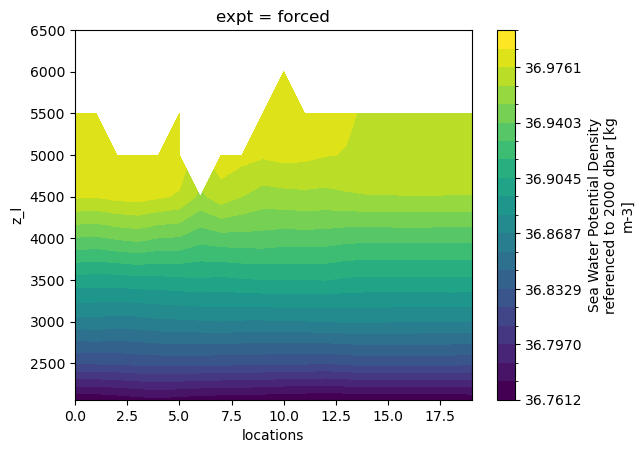

In [101]:
ds_cropped.sel(expt = "forced").mean("year").sigma2_offline.plot.contourf(levels = 21, vmax = 37.0)

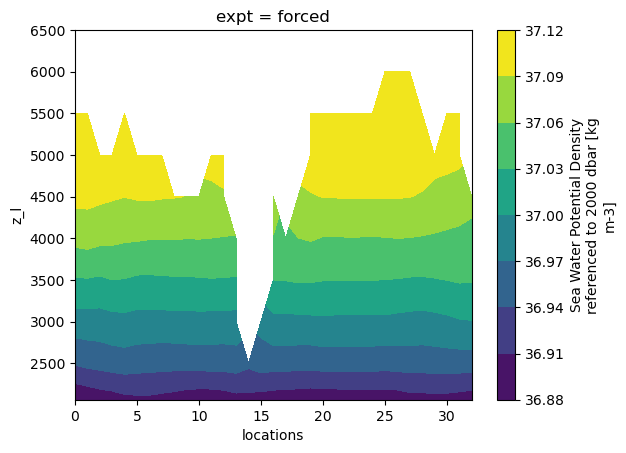

In [45]:
ds_cropped.sel(expt = "forced").mean("year").sigma2.plot.contourf()

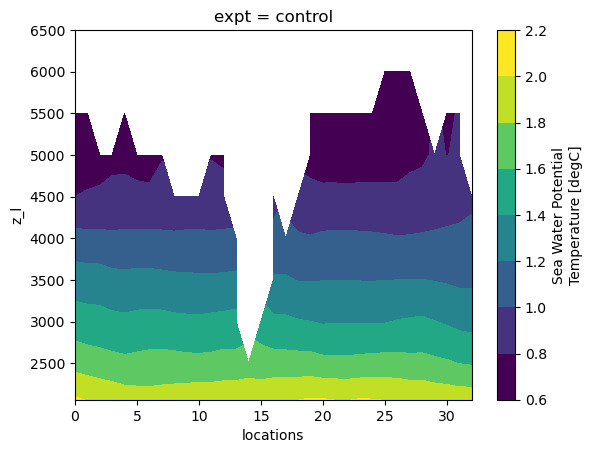

In [42]:
ds_cropped.sel(expt = "control").mean("year").thetao.plot.contourf()

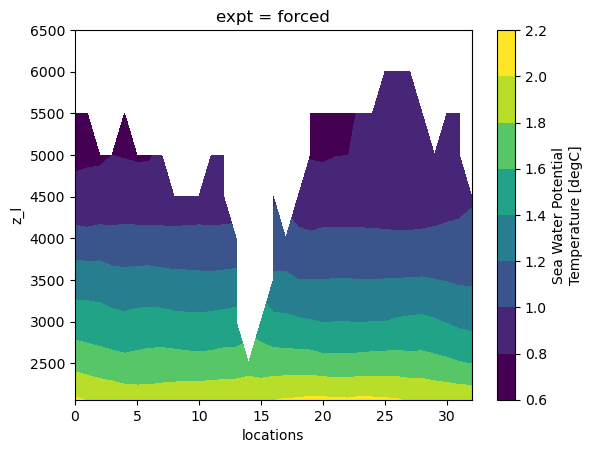

In [41]:
ds_cropped.sel(expt = "forced").mean("year").thetao.plot.contourf()

In [141]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def map_and_two_hovmollers_robinson(
    hov_left,
    hov_right,
    *,
    deptho,                       # REQUIRED: 2D bathymetry DataArray with coords geolon/geolat (or lon/lat)
    lon="geolon",
    lat="geolat",
    star_lonlat=(0.0, -75.0),
    extent=None,                  # (lon0, lon1, lat0, lat1) in PlateCarree, or None for global
    bathy_levels=(0, 200, 500, 1000, 2000, 3000, 4000, 5000),
    bathy_cmap=cm.cm.deep,
    left_title="control",
    right_title="forced",
    fig_title="",
    levels=None,
    cmap=None,
    units="",
    x="year",
    y="sigma",
    plot_contours=False,
):
    fig = plt.figure(figsize=(13, 4.0), constrained_layout=True)
    gs = fig.add_gridspec(1, 3, width_ratios=(1.0, 1.1, 1.1))

    axM = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
    axL = fig.add_subplot(gs[0, 1])
    axR = fig.add_subplot(gs[0, 2], sharex=axL, sharey=axL)

    if fig_title:
        fig.suptitle(fig_title, fontweight="bold", y=1.02)

    axM.add_feature(cfeature.LAND, zorder=3)
    axM.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=4)
    gl = axM.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=2, color='gray', alpha=0.1, linestyle='-')
    gl.top_labels = False
    gl.right_labels = False
    if extent is None:
        axM.set_global()
    else:
        axM.set_extent(extent, crs=ccrs.PlateCarree())

    bathy = np.abs(deptho)
    axM.contourf(
        deptho[lon], deptho[lat], bathy,
        levels=np.asarray(bathy_levels),
        cmap=bathy_cmap,
        transform=ccrs.PlateCarree(),
        zorder=1,
        extend="max",
    )

    lon_s, lat_s = star_lonlat
    axM.plot(
        lon_s, lat_s,
        marker="*", ms=12, mfc="yellow", mec="k", mew=0.8,
        transform=ccrs.PlateCarree(),
        zorder=10,
    )

    if levels is None:
        a = np.asarray(hov_left).ravel()
        a = a[np.isfinite(a)]
        levels = np.linspace(a.min(), a.max(), 21) if a.size else 21

    axL.set_facecolor("0.5")
    axR.set_facecolor("0.5")
    axL.set_title(left_title)
    axR.set_title(right_title)

    axL.contourf(hov_left[x], hov_left[y], hov_left, levels=levels, cmap=cmap, extend="both")
    cf = axR.contourf(hov_right[x], hov_right[y], hov_right, levels=levels, cmap=cmap, extend="both")

    if plot_contours:
        CS = axL.contour(hov_left[x], hov_left[y], hov_left, levels=levels, colors="k")
        axL.clabel(CS, CS.levels, fontsize=8)
        CS = axR.contour(hov_right[x], hov_right[y], hov_right, levels=levels, colors="k")
        axR.clabel(CS, CS.levels, fontsize=8)

    axL.set_xlabel(x)
    axR.set_xlabel(x)
    axL.set_ylabel(y)
    axR.tick_params(labelleft=False)

    fig.colorbar(cf, ax=[axL, axR], label=units, fraction=0.06, extend="both")
    return fig, (axM, axL, axR)


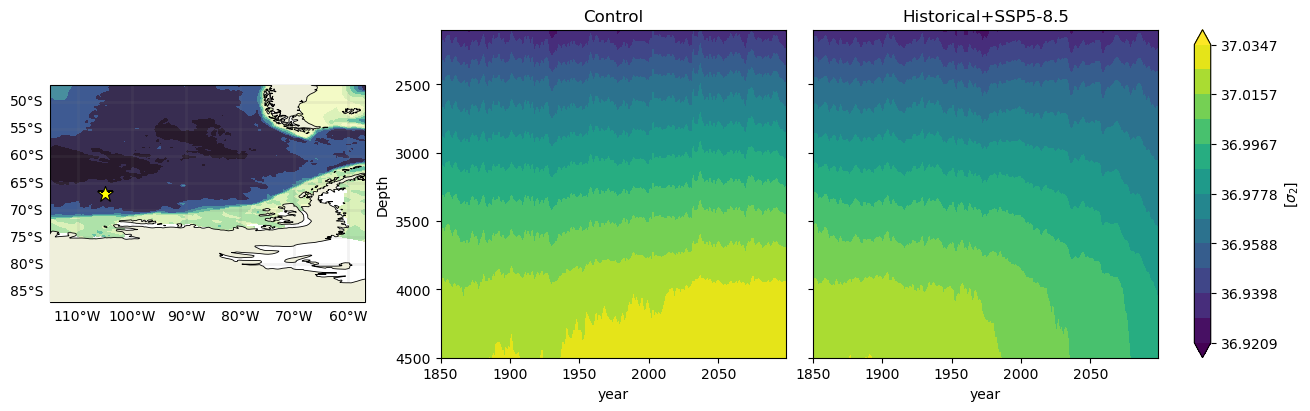

In [156]:
# your existing setup
location = 0
var = ds_cropped.sigma2_offline.isel(locations=location)
loc_lon = ds_locs.isel(locations=location).lon
loc_lat = ds_locs.isel(locations=location).lat

hov_control = var.sel(expt="control").T   # dims (z_l, year)
hov_forced  = var.sel(expt="forced").T

vmin = float(var.min())
vmax = float(var.max())
levels = np.linspace(vmin, vmax, 13)


fig, (axM, ax0, ax1) = map_and_two_hovmollers_robinson(
    hov_left=hov_control,
    hov_right=hov_forced,
    deptho=ds.deptho,           # <-- 2D bathymetry with geolon/geolat
    star_lonlat=(loc_lon, loc_lat),       # (lon, lat)
    extent=(loc_lon -10, loc_lat + 10, loc_lat-20, loc_lat+20),
    x="year",
    y="z_l",
    levels=levels,
    units=r"[$\sigma_2$]",
    left_title="Control",
    right_title="Historical+SSP5-8.5",
)
ax0.set_ylabel("Depth")   # since y="z_l" is positive down
ax0.set_ylim(2100, 4500)   # since y="z_l" is positive down
ax0.invert_yaxis()
plt.show()


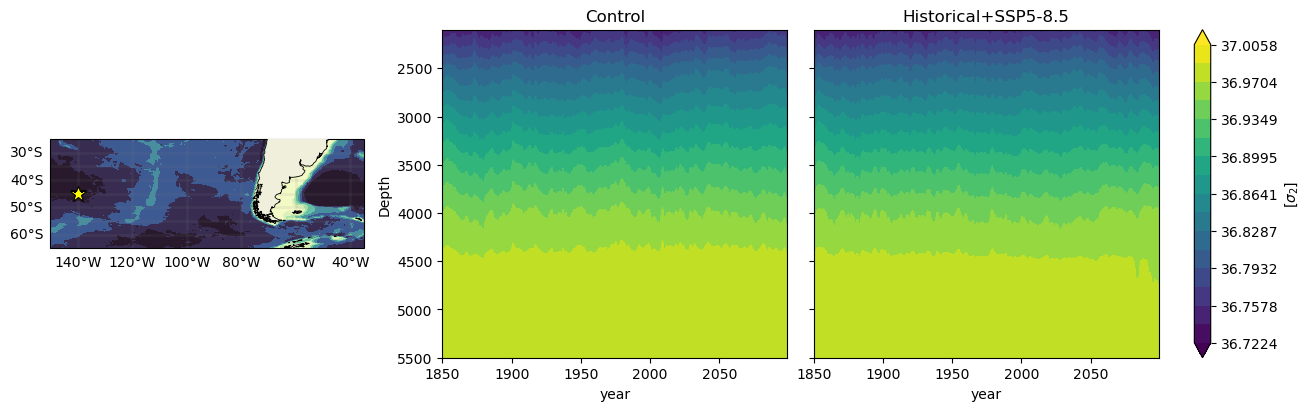

In [155]:
# your existing setup
location = 1
var = ds_cropped.sigma2_offline.isel(locations=location)
loc_lon = ds_locs.isel(locations=location).lon
loc_lat = ds_locs.isel(locations=location).lat

hov_control = var.sel(expt="control").T   # dims (z_l, year)
hov_forced  = var.sel(expt="forced").T

vmin = float(var.min())
vmax = float(var.max()) + 0.02
levels = np.linspace(vmin, vmax, 17)


fig, (axM, ax0, ax1) = map_and_two_hovmollers_robinson(
    hov_left=hov_control,
    hov_right=hov_forced,
    deptho=ds.deptho,           # <-- 2D bathymetry with geolon/geolat
    star_lonlat=(loc_lon, loc_lat),       # (lon, lat)
    extent=(loc_lon -10, loc_lat + 10, loc_lat-20, loc_lat+20),
    x="year",
    y="z_l",
    levels=levels,
    units=r"[$\sigma_2$]",
    left_title="Control",
    right_title="Historical+SSP5-8.5",
)
ax0.set_ylabel("Depth")   # since y="z_l" is positive down
ax0.set_ylim(2100, 5500)   # since y="z_l" is positive down
ax0.invert_yaxis()
plt.show()


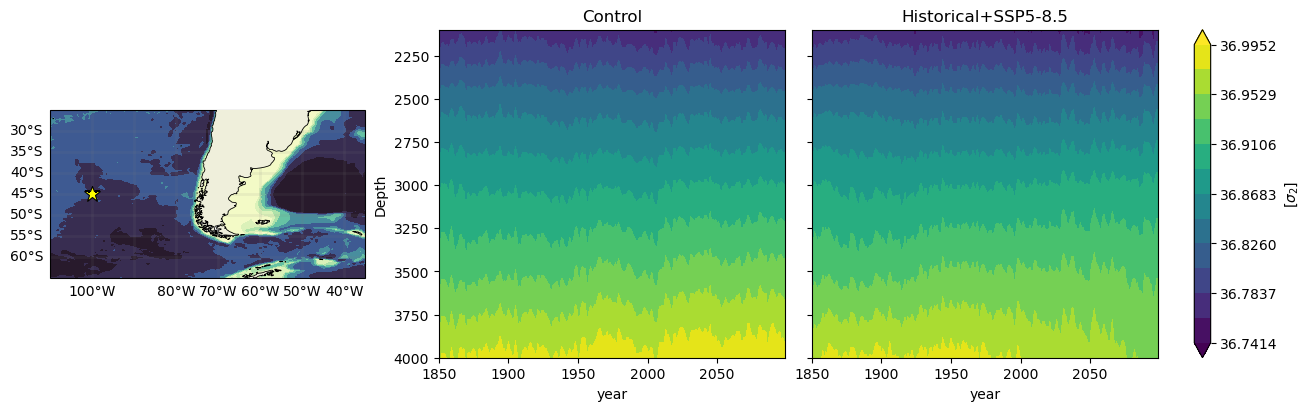

In [158]:
# your existing setup
location = 2
var = ds_cropped.sigma2_offline.isel(locations=location)
loc_lon = ds_locs.isel(locations=location).lon
loc_lat = ds_locs.isel(locations=location).lat

hov_control = var.sel(expt="control").T   # dims (z_l, year)
hov_forced  = var.sel(expt="forced").T

vmin = float(var.min())
vmax = float(var.max())
levels = np.linspace(vmin, vmax, 13)


fig, (axM, ax0, ax1) = map_and_two_hovmollers_robinson(
    hov_left=hov_control,
    hov_right=hov_forced,
    deptho=ds.deptho,           # <-- 2D bathymetry with geolon/geolat
    star_lonlat=(loc_lon, loc_lat),       # (lon, lat)
    extent=(loc_lon -10, loc_lat + 10, loc_lat-20, loc_lat+20),
    x="year",
    y="z_l",
    levels=levels,
    units=r"[$\sigma_2$]",
    left_title="Control",
    right_title="Historical+SSP5-8.5",
)
ax0.set_ylabel("Depth")   # since y="z_l" is positive down
ax0.set_ylim(2100, 4000)   # since y="z_l" is positive down
ax0.invert_yaxis()
plt.show()
